# 02 — Food & Nutrition Analysis

Exposure of the packaged-food market to an A–E front-of-pack label, using the **official Open Food Facts Nutri-Score**. D/E = would receive a Red flag.

In [1]:
import sys, json
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FINAL = ROOT / 'data' / 'final'
CLEAN = ROOT / 'data' / 'cleaned'
RAW = ROOT / 'data' / 'raw'
metrics = json.loads((ROOT / 'reports' / 'computed_metrics.json').read_text())
pd.set_option('display.max_columns', 40)


In [2]:
df = pd.read_csv(FINAL / 'food_market_analytics.csv', low_memory=False)
print(df.shape)
df[['product_name','brand_clean','category','nutrition_grade','nutrition_score']].head()

(220315, 15)


,product_name,brand_clean,category,nutrition_grade,nutrition_score
0,Banana Chips Sweetened (Whole),Unknown,"Chips, Crisps & Salty Snacks",D,4
1,Peanuts,Torn & Glasser,"Nuts, Seeds & Dried Fruit",B,2
2,Organic Salted Nut Mix,Grizzlies,Other / Unclassified,D,4
3,Organic Muesli,Daddy'S Muesli,Breakfast Cereals & Muesli,C,3
4,Zen Party Mix,Sunridge,Other / Unclassified,D,4


## Q1 — Overall grade distribution

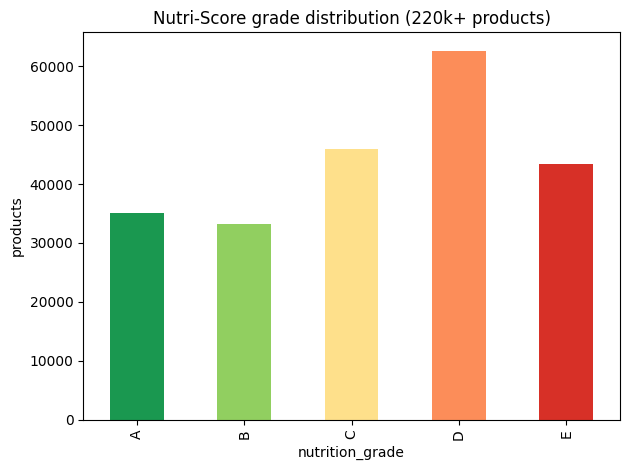

D/E (Red) exposure: 48.1%


In [3]:
dist = df['nutrition_grade'].value_counts().reindex(list('ABCDE'))
ax = dist.plot(kind='bar', color=['#1a9850','#91cf60','#fee08b','#fc8d59','#d73027'])
ax.set_title('Nutri-Score grade distribution (220k+ products)')
ax.set_ylabel('products'); plt.tight_layout(); plt.show()
de = df['nutrition_grade'].isin(['D','E']).mean()*100
print(f'D/E (Red) exposure: {de:.1f}%')

## Nutrient profile by grade
A sensible grade should show rising energy/sugar as it worsens.

In [4]:
prof = (df.groupby('nutrition_grade')[['energy_kj_100g','sugars_g_100g',
        'sodium_mg_100g','proteins_g_100g']].mean().round(1).reindex(list('ABCDE')))
prof

,energy_kj_100g,sugars_g_100g,sodium_mg_100g,proteins_g_100g
nutrition_grade,,,,
A,732.1,3.5,132.6,8.4
B,526.5,5.1,210.5,5.3
C,994.6,11.1,689.4,7.0
D,1472.6,20.9,645.3,8.6
E,1778.6,26.0,568.5,8.8


## Q2 — Category exposure league table

In [5]:
cat = pd.read_csv(FINAL / 'category_exposure.csv').sort_values('de_pct', ascending=False)
cat.head(10)

,category,products,de_pct,ab_pct,avg_score,avg_sugar_g,avg_sodium_mg,avg_satfat_proxy_fat_g,avg_energy_kj
0,Chocolate & Confectionery,23563,85.78,4.74,4.29,39.18,180.41,19.32,1740.39
1,"Biscuits, Cookies & Wafers",7329,81.63,5.03,4.19,23.69,407.94,17.80,1809.08
2,Cheese,11448,74.64,13.29,4.00,2.19,647.72,20.69,1255.85
3,Edible Oils & Fats,398,73.87,15.58,4.02,0.50,398.37,65.40,2580.71
4,"Cakes, Pastries & Sweet Bakery",8739,70.34,11.76,3.82,21.70,374.72,15.74,1443.35
5,"Spreads, Jam, Honey & Syrups",6195,64.28,14.58,3.65,32.51,226.58,12.49,1252.85
6,Ice Cream & Frozen Desserts,2547,62.27,4.83,3.58,21.43,91.13,9.15,857.31
7,"Sugar, Sweeteners & Baking",558,60.57,23.30,3.34,47.81,389.21,5.52,1312.11
8,"Nuts, Seeds & Dried Fruit",6759,52.60,15.27,3.42,15.92,241.91,36.23,2088.67
9,"Chips, Crisps & Salty Snacks",7456,51.82,12.67,3.45,7.54,636.34,22.30,1903.50


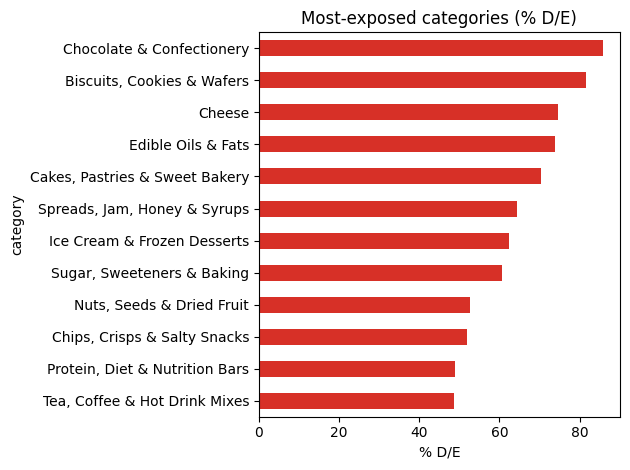

In [6]:
top = cat.head(12).set_index('category')['de_pct']
ax = top.sort_values().plot(kind='barh', color='#d73027')
ax.set_title('Most-exposed categories (% D/E)'); ax.set_xlabel('% D/E')
plt.tight_layout(); plt.show()

## Q3 — Brand exposure (≥80 products)

In [7]:
brand = pd.read_csv(FINAL / 'brand_exposure.csv')
print('most exposed:'); display(brand.sort_values('de_pct', ascending=False).head(10))
print('best positioned:'); display(brand.sort_values('ab_pct', ascending=False).head(10))

most exposed:


,brand_clean,products,ab_pct,c_pct,de_pct,avg_score
0,Lindt,511,0.0,0.00,100.00,4.97
1,Milka,241,0.0,0.00,100.00,4.95
2,Frey,141,0.0,0.00,100.00,4.92
3,Ritter Sport,112,0.0,0.00,100.00,5.00
4,Peeps,87,0.0,0.00,100.00,4.17
5,Cote D'Or,137,0.0,0.73,99.27,4.84
6,Ghirardelli Chocolate,134,0.0,0.75,99.25,4.90
7,Little Debbie,122,0.0,0.82,99.18,4.82
8,Target Corporation,95,0.0,1.05,98.95,4.68
9,Hammond'S,92,0.0,1.09,98.91,4.55


best positioned:


,brand_clean,products,ab_pct,c_pct,de_pct,avg_score
359,Notre Jardin,140,98.57,1.43,0.00,1.14
360,Chobani,117,97.44,2.56,0.00,1.26
361,Bush'S Best,112,96.43,3.57,0.00,1.31
357,Bonduelle,240,96.25,3.75,0.00,1.31
356,Dannon,273,95.97,4.03,0.00,1.48
364,Hanover,92,94.57,5.43,0.00,1.25
355,D'Aucy,141,94.33,4.96,0.71,1.25
363,The Pictsweet Company,104,94.23,5.77,0.00,1.19
353,Sojasun,105,93.33,5.71,0.95,1.68
358,Birds Eye,152,92.76,7.24,0.00,1.54


## Statistical tests
Formal backing for the headline claims (computed in `src/analysis/statistics.py`).

In [8]:
stat = metrics['statistics']
for k, v in stat.items():
    print('—', k)
    print('   ', v.get('interpretation',''))


— T1_ssb_vs_rest_DE_proportion
    The broad SSB bucket is polarised: ~39.2% grade B (diet/zero/low-sugar variants) and ~29.7% grade E (full-sugar), so its overall D/E share (44.2%) sits marginally below the market average. Isolating genuine full-sugar colas/energy drinks lifts D/E to 85.3%, above market. A label would sharply split the beverage aisle rather than condemn it uniformly.
— T2_sugar_choc_vs_dairy
    
— T3_grade_vs_category_independence
    grade is strongly associated with category -> category is a primary driver of exposure
— T4_energy_vs_grade_correlation
    
— T5_market_DE_share_CI
    


### Takeaway
~48% of products are D/E; exposure is concentrated in confectionery, biscuits, cheese and oils; the grade tracks energy/sugar monotonically; and category explains a large share of grade variation (χ², Cramér's V).